# Smart Grid Energy Management — Random Forest

**Module:** Machine Learning  
**Algorithm:** Random Forest Regressor (Supervised Learning)  
**Dataset:** Energy Consumption, Generation, Prices & Weather (Spain) — Kaggle  
**Dataset URL:** https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather

---

## Problem Statement

The goal is to predict the **Actual Electricity Price** (€/MWh) in the Spanish energy market based on historical load, generation, and weather data. This prediction is crucial for smart grid operators to make informed decisions about energy storage and grid balancing.

### Key Design Decisions
| Component | Design |
|---|---|
| **Target Variable** | `price actual` (Continuous) |
| **Predictor Features** | Load, Solar/Wind Generation, Fossil Gas, Hour, Month, Day of Week, Temperature |
| **Model** | Random Forest Regressor — Ensemble of Decision Trees |
| **Evaluation** | MAE, RMSE, and R² Score |

## 1. Imports & Style Configuration

In [7]:
# Standard library
import os
import warnings
warnings.filterwarnings('ignore')

# Numerical / data
import numpy as np
import pandas as pd

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Styling
SEED = 42
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_theme(style='whitegrid')

print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Dataset Loading & Preprocessing

Following the approach in the RL notebooks, we merge the `energy_dataset.csv` with aggregated weather features.

In [8]:
ENERGY_FILE  = '../data/energy_dataset.csv'
WEATHER_FILE = '../data/weather_features.csv'

energy_df  = pd.read_csv(ENERGY_FILE,  parse_dates=['time'])
weather_df = pd.read_csv(WEATHER_FILE, parse_dates=['dt_iso'])

# Aggregate weather to hourly (merging multiple cities)
weather_agg = (
    weather_df
    .rename(columns={'dt_iso': 'time'})
    .groupby('time')[['temp', 'wind_speed', 'clouds_all']]
    .mean()
    .reset_index()
)

# Handle timezones
energy_df['time'] = pd.to_datetime(energy_df['time'], utc=True).dt.tz_localize(None)
weather_agg['time'] = pd.to_datetime(weather_agg['time'], utc=True).dt.tz_localize(None)

# Merge
df = energy_df.merge(weather_agg, on='time', how='left')

# Feature Selection
core_cols = {
    'price actual': 'price',
    'total load actual': 'load',
    'generation solar': 'solar',
    'generation wind onshore': 'wind',
    'generation fossil gas': 'gas',
    'temp': 'temp'
}

df = df[['time'] + list(core_cols.keys())].rename(columns=core_cols)

# Cleaning
df.dropna(subset=['price', 'load'], inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

# Feature Engineering
df['hour'] = df['time'].dt.hour
df['month'] = df['time'].dt.month
df['day_of_week'] = df['time'].dt.dayofweek

print(f"Final Dataset Shape: {df.shape}")
df.head()

Final Dataset Shape: (35028, 10)


,time,price,load,solar,wind,gas,temp,hour,month,day_of_week
0,2014-12-31 23:00:00,65.41,25385.0,49.0,6378.0,4844.0,272.491463,23,12,2
1,2015-01-01 00:00:00,64.92,24382.0,50.0,5890.0,5196.0,272.512700,0,1,3
2,2015-01-01 01:00:00,64.48,22734.0,50.0,5461.0,4857.0,272.099137,1,1,3
3,2015-01-01 02:00:00,59.32,21286.0,50.0,5238.0,4314.0,272.089469,2,1,3
4,2015-01-01 03:00:00,56.04,20264.0,42.0,4935.0,4130.0,272.145900,3,1,3


## 3. Exploratory Data Analysis (EDA)

Understanding the relationship between price and other variables.

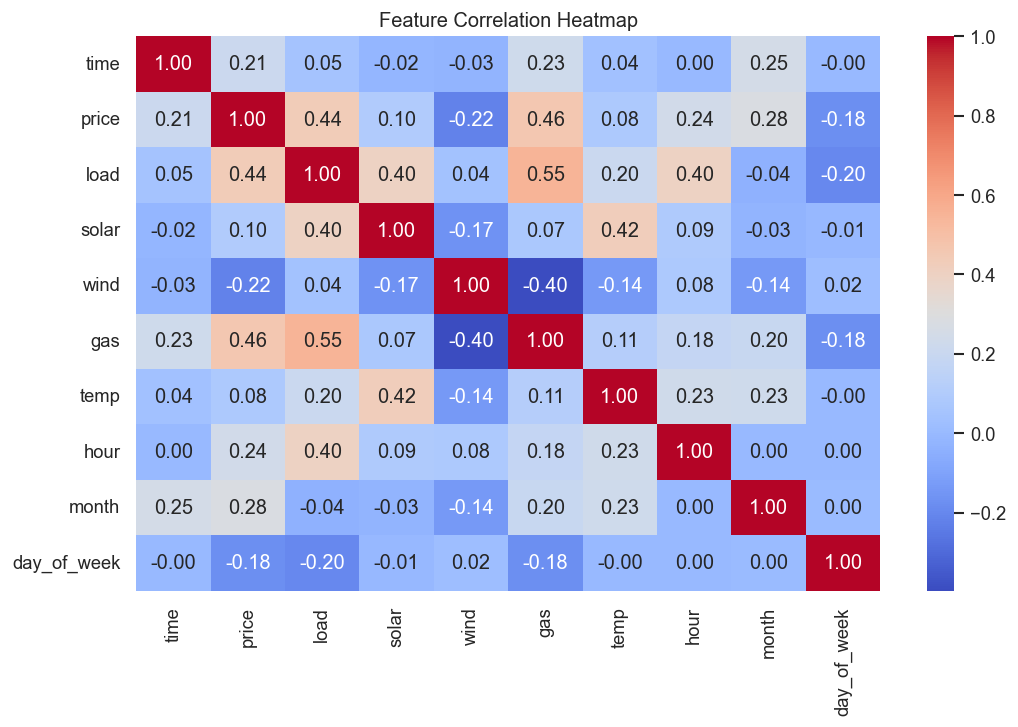

In [9]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

## 4. Training the Random Forest

We split the data and train an ensemble model.

In [10]:
features = ['load', 'solar', 'wind', 'gas', 'temp', 'hour', 'month', 'day_of_week']
X = df[features]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

print("Training Random Forest (100 estimators)...")
rf = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
print("Training finished.")

Training Random Forest (100 estimators)...
Training finished.


## 5. Quantitative Results

Measuring the model's accuracy on unseen test data.

In [11]:
y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

results = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2 Score'],
    'Value': [f"{mae:.4f} EUR/MWh", f"{rmse:.4f} EUR/MWh", f"{r2:.4f}"]
})

display(results)

,Metric,Value
0,MAE,5.2943 EUR/MWh
1,RMSE,7.0701 EUR/MWh
2,R2 Score,0.7439


## 6. Visual Analysis

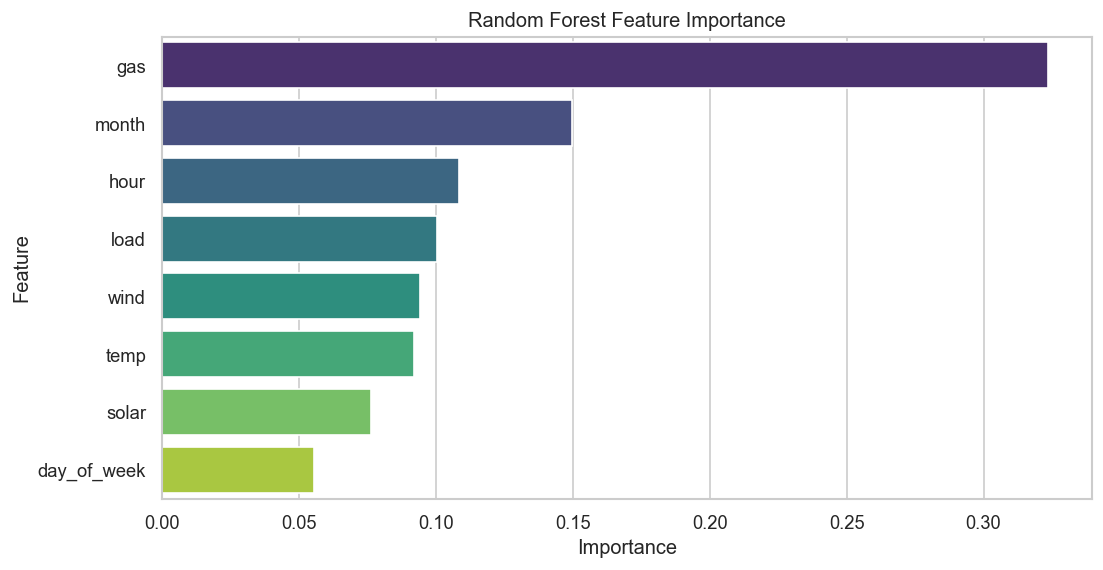

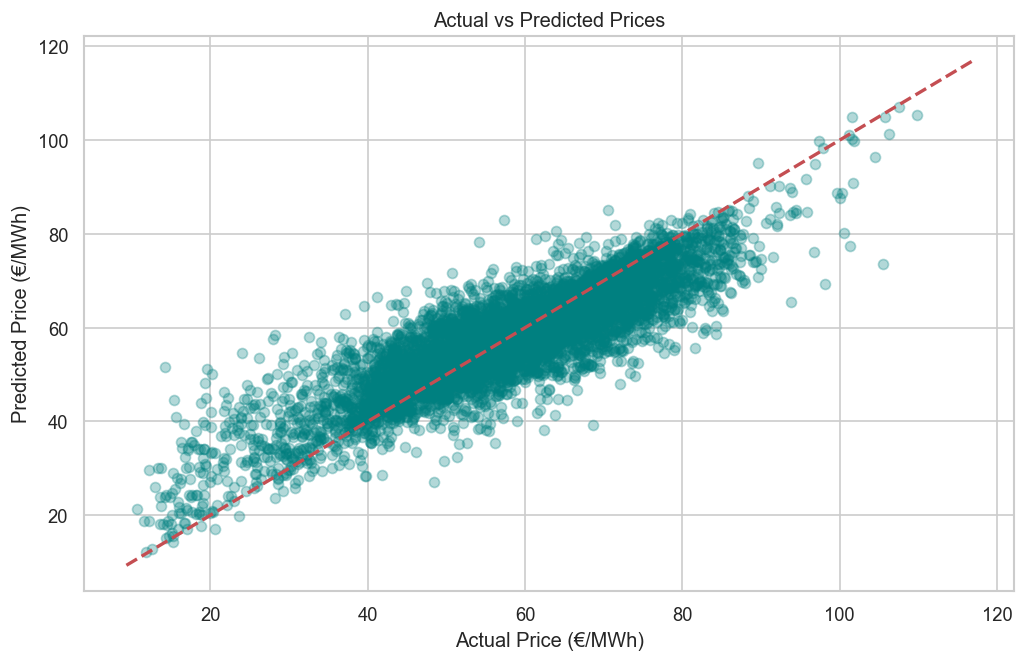

In [12]:
# Feature Importance
fi_df = pd.DataFrame({'Feature': features, 'Importance': rf.feature_importances_}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')
plt.title("Random Forest Feature Importance")
plt.show()

# Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r', lw=2)
plt.title("Actual vs Predicted Prices")
plt.xlabel("Actual Price (€/MWh)")
plt.ylabel("Predicted Price (€/MWh)")
plt.show()